# 1 The data are split in two files, load the files and merge them according to the first column, which is the index; both the files contain a "class" column, keep both the columns in the merged file calling them "class_x" and "class_y" (you can use the merge function of pandas dataframes)

In [2]:
import pandas as pd

df1 = pd.read_csv('written-test-2020-07-22-exam-1.csv',header=0, names=['idx','A','C','E','class'])
df2 = pd.read_csv('written-test-2020-07-22-exam-2.csv', header=0, names=['idx','B','D','F','class'])
df1

,idx,A,C,E,class
0,0,-0.386248,1.536628,1.232589,1
1,1,-2.686649,4.640702,0.823433,1
2,2,0.474124,1.576616,-1.256234,0
3,3,-1.343790,-0.514008,1.520392,2
4,4,-2.187600,0.289041,1.318321,2
...,...,...,...,...,...
1995,1995,-1.668710,1.258125,-1.111517,0
1996,1996,0.842932,-0.862210,-0.658845,2
1997,1997,1.371652,0.861149,-0.966656,0
1998,1998,2.091386,-0.164420,-1.185916,0


In [3]:
df = df1.merge(df2,how='inner',on='idx')
df

,idx,A,C,E,class_x,B,D,F,class_y
0,0,-0.386248,1.536628,1.232589,1,-1.432057,1.039420,0.280469,1
1,1,-2.686649,4.640702,0.823433,1,-4.036329,0.526320,-0.419013,1
2,2,0.474124,1.576616,-1.256234,0,0.179770,0.157974,-0.162869,0
3,3,-1.343790,-0.514008,1.520392,2,-1.299109,-0.152250,0.045123,2
4,4,-2.187600,0.289041,1.318321,2,-2.089699,-0.494995,-0.661858,2
...,...,...,...,...,...,...,...,...,...
1995,1995,-1.668710,1.258125,-1.111517,0,-1.114765,-1.209808,1.546161,0
1996,1996,0.842932,-0.862210,-0.658845,2,1.188689,-0.174914,-1.376579,2
1997,1997,1.371652,0.861149,-0.966656,0,0.929550,0.616987,-0.643962,0
1998,1998,2.091386,-0.164420,-1.185916,0,1.918095,0.557593,-0.942563,0


# 2 Delete all the rows where class_x is different from class_y, then drop class_y and rename class_x as class

In [4]:
df = df[df['class_x']==df['class_y']]
df = df.drop(columns='class_y')
df = df.rename(columns={'class_x':'class'})

In [5]:
df

,idx,A,C,E,class,B,D,F
0,0,-0.386248,1.536628,1.232589,1,-1.432057,1.039420,0.280469
1,1,-2.686649,4.640702,0.823433,1,-4.036329,0.526320,-0.419013
2,2,0.474124,1.576616,-1.256234,0,0.179770,0.157974,-0.162869
3,3,-1.343790,-0.514008,1.520392,2,-1.299109,-0.152250,0.045123
4,4,-2.187600,0.289041,1.318321,2,-2.089699,-0.494995,-0.661858
...,...,...,...,...,...,...,...,...
1995,1995,-1.668710,1.258125,-1.111517,0,-1.114765,-1.209808,1.546161
1996,1996,0.842932,-0.862210,-0.658845,2,1.188689,-0.174914,-1.376579
1997,1997,1.371652,0.861149,-0.966656,0,0.929550,0.616987,-0.643962
1998,1998,2.091386,-0.164420,-1.185916,0,1.918095,0.557593,-0.942563


# 3 Reorder the columns in alphabetical order, but placing the class column as the last one; the cleaned dataframe must be named df; show its size and head

In [6]:
#df6 = df.sort_index(axis=1)
df = df.reindex(columns=['idx','A','B','C','D','E','F','class'])
df

,idx,A,B,C,D,E,F,class
0,0,-0.386248,-1.432057,1.536628,1.039420,1.232589,0.280469,1
1,1,-2.686649,-4.036329,4.640702,0.526320,0.823433,-0.419013,1
2,2,0.474124,0.179770,1.576616,0.157974,-1.256234,-0.162869,0
3,3,-1.343790,-1.299109,-0.514008,-0.152250,1.520392,0.045123,2
4,4,-2.187600,-2.089699,0.289041,-0.494995,1.318321,-0.661858,2
...,...,...,...,...,...,...,...,...
1995,1995,-1.668710,-1.114765,1.258125,-1.209808,-1.111517,1.546161,0
1996,1996,0.842932,1.188689,-0.862210,-0.174914,-0.658845,-1.376579,2
1997,1997,1.371652,0.929550,0.861149,0.616987,-0.966656,-0.643962,0
1998,1998,2.091386,1.918095,-0.164420,0.557593,-1.185916,-0.942563,0


In [7]:
df.info()
print('----------------------------------------------')
df.describe()

<class 'pandas.DataFrame'>
Index: 1984 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   idx     1984 non-null   int64  
 1   A       1984 non-null   float64
 2   B       1984 non-null   float64
 3   C       1984 non-null   float64
 4   D       1984 non-null   float64
 5   E       1984 non-null   float64
 6   F       1984 non-null   float64
 7   class   1984 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 139.5 KB
----------------------------------------------


,idx,A,B,C,D,E,F,class
count,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000
mean,999.906754,0.014371,-0.118260,0.335195,0.114162,-0.033515,0.009895,1.001008
std,576.853283,1.451684,1.305484,1.265194,1.239324,1.400595,1.011391,0.817113
min,0.000000,-4.739618,-4.128180,-2.860388,-3.575283,-5.262167,-3.718638,0.000000
25%,500.750000,-1.084736,-1.099831,-0.695878,-0.777648,-1.096264,-0.660942,0.000000
50%,999.500000,-0.194714,-0.231122,0.459507,0.047184,-0.178261,0.019992,1.000000
75%,1499.250000,1.014071,0.876380,1.258427,0.901379,1.047042,0.698540,2.000000
max,1999.000000,4.958197,3.334964,5.286334,4.334060,4.752816,2.837571,2.000000


# 4 Find the best classification scheme using three classification methods

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

svm = make_pipeline(StandardScaler(), SVC())
svm_fitted = svm.fit(X_train,y_train)
y_pred_train_svm = svm_fitted.predict(X_train)
y_pred_test_svm = svm_fitted.predict(X_test)


print(' -----------Training classification report-----------')
print(classification_report(y_train,y_pred_train_svm))
print(' -----------Testing classification report-----------')
print(classification_report(y_test,y_pred_test_svm))

 -----------Training classification report-----------
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       548
           1       0.84      0.85      0.85       517
           2       0.92      0.93      0.93       522

    accuracy                           0.87      1587
   macro avg       0.87      0.87      0.87      1587
weighted avg       0.87      0.87      0.87      1587

 -----------Testing classification report-----------
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       113
           1       0.87      0.84      0.85       143
           2       0.89      0.95      0.92       141

    accuracy                           0.87       397
   macro avg       0.87      0.87      0.87       397
weighted avg       0.87      0.87      0.87       397



In [21]:
svm.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'standardscaler', 'svc', 'standardscaler__copy', 'standardscaler__with_mean', 'standardscaler__with_std', 'svc__C', 'svc__break_ties', 'svc__cache_size', 'svc__class_weight', 'svc__coef0', 'svc__decision_function_shape', 'svc__degree', 'svc__gamma', 'svc__kernel', 'svc__max_iter', 'svc__probability', 'svc__random_state', 'svc__shrinking', 'svc__tol', 'svc__verbose'])

In [12]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier()
neigh_fitted = neigh.fit(X_train,y_train)
y_pred_train_neigh = neigh_fitted.predict(X_train)
y_pred_test_neigh = neigh_fitted.predict(X_test)


print(' -----------Training classification report-----------')
print(classification_report(y_train,y_pred_train_neigh))
print(' -----------Testing classification report-----------')
print(classification_report(y_test,y_pred_test_neigh))

 -----------Training classification report-----------
              precision    recall  f1-score   support

           0       0.56      0.78      0.65       548
           1       0.65      0.60      0.62       517
           2       0.73      0.48      0.58       522

    accuracy                           0.62      1587
   macro avg       0.65      0.62      0.62      1587
weighted avg       0.64      0.62      0.62      1587

 -----------Testing classification report-----------
              precision    recall  f1-score   support

           0       0.31      0.56      0.40       113
           1       0.44      0.34      0.39       143
           2       0.51      0.30      0.38       141

    accuracy                           0.39       397
   macro avg       0.42      0.40      0.39       397
weighted avg       0.43      0.39      0.39       397



# 5 For each classification method find the best parameter setting with cross validation on the training set 

In [ ]:
from sklearn.model_selection import GridSearchCV

svm = make_pipeline(StandardScaler(), SVC())
grid_svm = {'svc__kernel':['linear', 'poly', 'rbf', 'sigmoid'],
            'svc__gamma': [1e-3, 1e-4],
             'svc__C': [1, 10, 100, 1000]}
gs_svm = GridSearchCV(estimator=svm,param_grid=grid_svm,cv=5)
gs_svm.fit(X_train,y_train)
print(gs_svm.best_params_)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=1000, gamma=0.001))])
{'svc__C': 1000, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


In [24]:
grid_neigh = {'n_neighbors':[1,5,10],
              'weights':['uniform','distance']}

gs_neigh = GridSearchCV(estimator=neigh,param_grid=grid_neigh,cv=5)
gs_neigh.fit(X_train,y_train)

print(gs_neigh.best_params_)


{'n_neighbors': 1, 'weights': 'uniform'}


In [25]:
svm_best = make_pipeline(StandardScaler(), SVC(C=1000, gamma=0.001, kernel='rbf'))
svm_fitted_best = svm_best.fit(X_train,y_train)
y_pred_train_svm_best = svm_fitted_best.predict(X_train)
y_pred_test_svm_best = svm_fitted_best.predict(X_test)


print(' -----------Training classification report-----------')
print(classification_report(y_train,y_pred_train_svm_best))
print(' -----------Testing classification report-----------')
print(classification_report(y_test,y_pred_test_svm_best))

 -----------Training classification report-----------
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       548
           1       0.80      0.80      0.80       517
           2       0.88      0.89      0.89       522

    accuracy                           0.83      1587
   macro avg       0.83      0.83      0.83      1587
weighted avg       0.83      0.83      0.83      1587

 -----------Testing classification report-----------
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       113
           1       0.85      0.82      0.84       143
           2       0.85      0.92      0.88       141

    accuracy                           0.85       397
   macro avg       0.85      0.84      0.84       397
weighted avg       0.85      0.85      0.85       397



In [26]:
from sklearn.neighbors import KNeighborsClassifier

neigh_best = KNeighborsClassifier(n_neighbors=1, weights='uniform')
neigh_fitted_best = neigh_best.fit(X_train,y_train)
y_pred_train_neigh_best = neigh_fitted_best.predict(X_train)
y_pred_test_neigh_best = neigh_fitted_best.predict(X_test)


print(' -----------Training classification report-----------')
print(classification_report(y_train,y_pred_train_neigh_best))
print(' -----------Testing classification report-----------')
print(classification_report(y_test,y_pred_test_neigh_best))

 -----------Training classification report-----------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       548
           1       1.00      1.00      1.00       517
           2       1.00      1.00      1.00       522

    accuracy                           1.00      1587
   macro avg       1.00      1.00      1.00      1587
weighted avg       1.00      1.00      1.00      1587

 -----------Testing classification report-----------
              precision    recall  f1-score   support

           0       0.39      0.57      0.46       113
           1       0.63      0.45      0.52       143
           2       0.58      0.53      0.55       141

    accuracy                           0.51       397
   macro avg       0.53      0.52      0.51       397
weighted avg       0.54      0.51      0.52       397



# 6 For each classification method compute the accuracy and the confusion matrix on the test set 

In [44]:
from sklearn.metrics import accuracy_score
accs = pd.DataFrame(columns=['model','accuracy'])
test_acc_svm = accuracy_score(y_test,y_pred_test_svm_best)
accs.loc[len(accs)] = ['SVM', test_acc_svm]
print(f"SVM Testing Accuracy: {test_acc_svm:.2f}")

test_acc_neigh = accuracy_score(y_test,y_pred_test_neigh_best)
accs.loc[len(accs)] = ['KNeighbors', test_acc_neigh]
print(f"KNeighbors Testing Accuracy: {test_acc_neigh:.2f}")

SVM Testing Accuracy: 0.85
KNeighbors Testing Accuracy: 0.51


In [46]:
accs

,model,accuracy
0,SVM,0.846348
1,KNeighbors,0.511335


# 7 Produce a plot of the accuracies given by the methods attempted

<Axes: xlabel='model', ylabel='accuracy'>

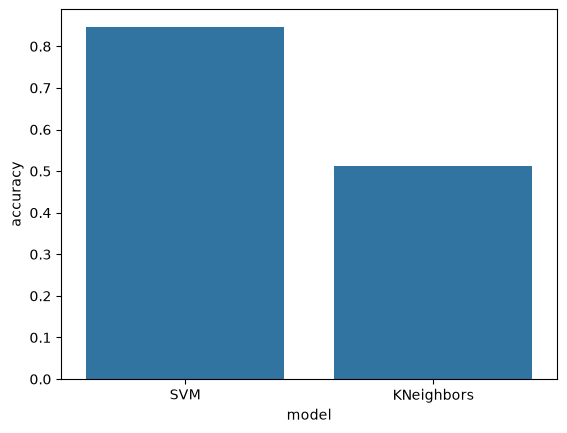

In [47]:
import seaborn as sns

sns.barplot(accs,x='model',y='accuracy')
